**UNIVERSIDAD ESTATAL AMAZÓNICA**
Integrantes: Luis Gilmmar Lugo Chica ;  Maritza Estefany Jiron Jimenez

Paralelo: B

Asignatura: Mineria de Datos

Profesor: Dr. Delfín Bernabé Ortega Tenezaca

**FASE 1 Carga y Filtrado Inicial**

In [27]:
#Importacion de las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [28]:
# 1. Cargar el dataset desde github
url = "https://raw.githubusercontent.com/bisho1994/dataset_cne/refs/heads/main/diabetes.csv"
df_crudo = pd.read_csv(url)

**Diccionario de Datos del Dataset**

| Variable | Tipo de Dato | Categoría | Descripción |
| :--- | :--- | :--- | :--- |
| **`id`** | Numérico | Demográfico | Identificador único y anónimo de cada paciente. |
| **`chol`** | Numérico | Laboratorio | Colesterol total en sangre (medido en mg/dL). |
| **`stab.glu`** | Numérico | Laboratorio | Glucosa estable en sangre (en ayunas). |
| **`hdl`** | Numérico | Laboratorio | Lipoproteína de alta densidad ('colesterol bueno'). |
| **`ratio`** | Numérico | Laboratorio | Relación matemática entre el colesterol total y el HDL (`chol / hdl`). |
| **`glyhb`** | Numérico | Laboratorio | Hemoglobina glicosilada (A1c). Variable clave para el diagnóstico. |
| **`location`** | Texto | Demográfico | Condado rural de origen del paciente (*Buckingham* o *Louisa*). |
| **`age`** | Numérico | Demográfico | Edad del paciente en años. |
| **`gender`** | Texto | Demográfico | Género biológico del paciente (*male* / *female*). |
| **`frame`** | Texto | Antropométrico | Tamaño de la estructura corporal (*small*, *medium*, *large*). |
| **`weight`** | Numérico | Antropométrico | Peso del paciente (medido en libras). |
| **`height`** | Numérico | Antropométrico | Altura del paciente (medida en pulgadas). |
| **`bp.1s`** | Numérico | Signos Vitales | Primera medición de la presión arterial sistólica (valor alto). |
| **`bp.1d`** | Numérico | Signos Vitales | Primera medición de la presión arterial diastólica (valor bajo). |
| **`bp.2s`** | Numérico | Signos Vitales | Segunda medición de la presión arterial sistólica (si aplica). |
| **`bp.2d`** | Numérico | Signos Vitales | Segunda medición de la presión arterial diastólica (si aplica). |
| **`waist`** | Numérico | Antropométrico | Circunferencia de la cintura (medida en pulgadas). |
| **`hip`** | Numérico | Antropométrico | Circunferencia de la cadera (medida en pulgadas). |
| **`diabetes`** | Numérico | Objetivo (Target) | Diagnóstico final del paciente (1 si es diabético, 0 si no lo es). |

"Se utilizó el comando df.head() para realizar una inspección visual inicial de las primeras filas del conjunto de datos, permitiendo verificar la correcta carga del archivo y la alineación de las columnas. Paralelamente, se aplicó df.info() para obtener un resumen estructural que detalla el tipo de dato de cada variable, el conteo de registros no nulos y la detección temprana de valores faltantes (NaN)."

**Análisis Estructural del Conjunto de Datos (Auditoría de Datos)**

In [29]:
df_crudo.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [30]:
df_crudo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403 entries, 0 to 402
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        403 non-null    int64  
 1   chol      402 non-null    float64
 2   stab.glu  403 non-null    int64  
 3   hdl       402 non-null    float64
 4   ratio     402 non-null    float64
 5   glyhb     390 non-null    float64
 6   location  403 non-null    object 
 7   age       403 non-null    int64  
 8   gender    403 non-null    object 
 9   height    398 non-null    float64
 10  weight    402 non-null    float64
 11  frame     391 non-null    object 
 12  bp.1s     398 non-null    float64
 13  bp.1d     398 non-null    float64
 14  bp.2s     141 non-null    float64
 15  bp.2d     141 non-null    float64
 16  waist     401 non-null    float64
 17  hip       401 non-null    float64
 18  time.ppn  400 non-null    float64
dtypes: float64(13), int64(3), object(3)
memory usage: 59.9+ KB


Para evaluar la calidad, integridad y viabilidad del conjunto de datos antes de proceder con el modelado predictivo, se realizó una auditoría estructural mediante la función df.info().

 Los hallazgos clave se describen a continuación:

 **Dimensiones y Tipos de Datos**

 El dataset cuenta con un volumen inicial de 403 registros (pacientes) y 19 variables (columnas).

 Desde el punto de vista computacional, los tipos de datos han sido correctamente indexados por el intérprete en tres categorías:

 13 variables cuantitativas continuas (float64), que representan la mayoría de las métricas de laboratorio y antropométricas.

 3 variables cuantitativas discretas (int64), correspondientes al identificador del paciente, la edad y la glucosa en ayunas.

 3 variables cualitativas/categóricas (object), que corresponden a variables de texto: género (gender), ubicación geográfica (location) y complexión física (frame).

 Estas requerirán un proceso de codificación numérica (Encoding) previo a la fase de Machine Learning.

 Diagnóstico de Datos Faltantes (Valores Nulos)

 El análisis revela que el dataset presenta problemas de completitud en variables críticas, lo que exige una estrategia de limpieza obligatoria:

 Columnas candidatas a eliminación (bp.2s y bp.2d):

 Las variables que registran la segunda toma de presión arterial presentan únicamente 141 registros válidos de 403 posibles. Esto representa un 65% de datos faltantes. Al no ser estadísticamente representativas, se sugiere descartar estas variables para evitar ruido en los modelos.

 Compromiso de la Variable Objetivo (glyhb): La hemoglobina glicosilada, métrica fundamental para el diagnóstico de la diabetes en este estudio, reporta 390 registros no nulos.

Existen 13 pacientes sin este dato, los cuales deberán ser removidos del análisis categórico para no sesgar las etiquetas de entrenamiento.

Incompletitud Menor: Se detectaron pérdidas marginales de información en variables como la estructura corporal (frame con 12 nulos), estatura (height con 5 nulos) y colesterol total (chol con 1 nulo), las cuales son aptas para técnicas de imputación por media o moda.

**Porcentaje de valores nulos por variable**

In [31]:
# 1. Calcular la cantidad absoluta de valores nulos por variable
cantidad_nulos = df_crudo.isnull().sum()

# 2. Calcular el porcentaje de valores nulos por variable (redondeado a 2 decimales)
porcentaje_nulos = (df_crudo.isnull().mean() * 100).round(2)

# 3. Unir ambos resultados en un DataFrame limpio para tu informe
reporte_nulos = pd.DataFrame(
    {
        'Cantidad Nulos': cantidad_nulos,
        'Porcentaje (%)': porcentaje_nulos,
        'Tipo de Dato': df_crudo.dtypes,
    }
)

# Mostrar ordenado de mayor a menor porcentaje de nulos
reporte_nulos = reporte_nulos.sort_values(by='Porcentaje (%)', ascending=False)

print(reporte_nulos)

          Cantidad Nulos  Porcentaje (%) Tipo de Dato
bp.2d                262           65.01      float64
bp.2s                262           65.01      float64
glyhb                 13            3.23      float64
frame                 12            2.98       object
bp.1s                  5            1.24      float64
bp.1d                  5            1.24      float64
height                 5            1.24      float64
time.ppn               3            0.74      float64
waist                  2            0.50      float64
hip                    2            0.50      float64
chol                   1            0.25      float64
weight                 1            0.25      float64
ratio                  1            0.25      float64
hdl                    1            0.25      float64
id                     0            0.00        int64
stab.glu               0            0.00        int64
age                    0            0.00        int64
location               0    

Cantidad y el porcentaje de registros duplicados.


In [32]:
# 1. Calcular la cantidad total de registros duplicados
cantidad_duplicados = df_crudo.duplicated().sum()

# 2. Obtener el número total de registros en el dataset
total_registros = len(df_crudo)

# 3. Calcular el porcentaje de registros duplicados
porcentaje_duplicados = (cantidad_duplicados / total_registros) * 100

# Mostrar los resultados formateados
print(f"Cantidad de registros duplicados: {cantidad_duplicados}")
print(f"Porcentaje de registros duplicados: {porcentaje_duplicados:.2f}% del total de filas.")

Cantidad de registros duplicados: 0
Porcentaje de registros duplicados: 0.00% del total de filas.


**valores atípicos (IQR)**

In [33]:
import numpy as np
import pandas as pd

# Seleccionar solo las columnas numéricas del dataset limpio
columnas_numericas = df_limpio.select_dtypes(include=[np.number]).columns

reporte_outliers = []

for col in columnas_numericas:
  Q1 = df_limpio[col].quantile(0.25)
  Q3 = df_limpio[col].quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  # Filtrar valores atípicos
  outliers = df_limpio[(df_limpio[col] < limite_inferior) | (df_limpio[col] > limite_superior)]
  cantidad = len(outliers)
  porcentaje = (cantidad / len(df_limpio)) * 100

  reporte_outliers.append({
      'Variable': col,
      'Cantidad Outliers': cantidad,
      'Porcentaje (%)': round(porcentaje, 2),
      'Límite Inferior': round(limite_inferior, 2),
      'Límite Superior': round(limite_superior, 2),
  })

df_outliers = pd.DataFrame(reporte_outliers)
print(df_outliers)

    Variable  Cantidad Outliers  Porcentaje (%)  Límite Inferior  \
0       chol                 11            2.82           104.00   
1   stab.glu                 50           12.82            40.88   
2        hdl                 13            3.33             6.50   
3      ratio                  6            1.54            -0.10   
4      glyhb                 57           14.62             2.55   
5        age                  0            0.00            -5.00   
6     height                  1            0.26            54.00   
7     weight                 10            2.56            76.00   
8      bp.1s                 12            3.08            83.00   
9      bp.1d                 13            3.33            52.50   
10     waist                  2            0.51            21.00   
11       hip                 12            3.08            28.50   
12  time.ppn                 10            2.56          -495.00   
13       bmi                  8            2.05 

**Estadística Descriptiva**

In [34]:
df_crudo.describe()

,id,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,403.000000,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,15978.310174,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,11881.122124,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,1000.000000,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,4792.500000,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,15766.000000,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,20336.000000,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,41756.000000,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


Tras ejecutar el análisis estadistico descriptivo sobre las variables cuantitativas de la muestra, se obtuvieron las métricas fundamentales de tendencia central y dispersión. El estudio del comportamiento biométrico y clínico de los 403 pacientes revela las siguientes conclusiones:

**Caracterización Demográfica (Edad)**

Edad Muestral: La población bajo estudio presenta una media de 46.8 años, con una desviación estándar de ±16.3 años.

Distribución: El paciente más joven registrado tiene 19 años, mientras que el participante de mayor longevidad alcanza los 92 años.
El 50% de la muestra (mediana) se concentra por debajo de los 45 años, lo que indica que se trata de una población predominantemente adulta-joven y de mediana edad.

**Evaluación Antropométrica y de Composición Corporal**

**Estatura y Peso:**

La estatura promedio se sitúa en las 66 pulgadas (1.67 metros). El peso corporal medio de la muestra es de 177.5 libras (80.5 kg). Sin embargo, se observa una alta variabilidad genética o de condiciones metabólicas, registrándose un peso mínimo de 99 libras (44.9 kg) y un máximo crítico de 325 libras (147.4 kg).

Distribución de Grasa (Cintura y Cadera): La circunferencia de la cintura promedia las 37.9 pulgadas (96.2 cm), alcanzando un máximo alarmante de 56 pulgadas (142.2 cm). La cadera promedia 43 pulgadas (109.2 cm), con un pico máximo de 64 pulgadas. Estos valores sugieren, de manera preliminar, una prevalencia considerable de obesidad abdominal y sobrepeso en un porcentaje importante de la muestra.

**Perfil de Riesgo Clínico y Cardiovascular**

**Presión Arterial Inicial:** La primera toma de presión arterial sistólica (bp.1s) reporta una media de 136.9 mmHg, cruzando el umbral clínico de la prehipertensión. El valor máximo detectado es de 250 mmHg, lo que representa una crisis hipertensiva grave en ciertos individuos.

Por su parte, la presión diastólica (bp.1d) promedia los 83.3 mmHg, con un máximo de 124 mmHg.Perfil Lipídico:

El colesterol total promedia los 207.8 mg/dL, valor que ya se considera ligeramente elevado (límite de riesgo). El rango se extiende desde un óptimo 78 mg/dL hasta un nivel severo de 443 mg/dL.

El colesterol "bueno" (hdl) promedia 50.4 mg/dL, pero cae a mínimos críticos de 12 mg/dL en pacientes de alto riesgo. Como consecuencia, la relación colesterol total/HDL (ratio) promedia 4.5 unidades, escalando hasta un preocupante máximo de 19.3 unidades.

**Espectro Metabólico y Variable Predictiva (Glucosa y Diabetes)**

Glucosa en Ayunas (stab.glu): Aunque el promedio general se sitúa en 106.6 mg/dL (indicativo de prediabetes leve en ayunas), la desviación estándar es muy elevada (±53.0 mg/dL). Se identificaron casos con niveles extremos de hasta 385 mg/dL, consistentes con cuadros severos de hiperglucemia.

Hemoglobina Glicosilada (glyhb): El promedio del indicador A1c es de 5.58%, manteniéndose globalmente en límites normales (< 5.7%). No obstante, el percentil 75% se sitúa en 5.60%, lo que significa que el 25% de la población evaluada ya se encuentra en rangos francos de prediabetes o diabetes establecida, alcanzando un valor máximo crítico de 16.11% (descontrol metabólico severo).

**Preprocesamiento de datos**

In [35]:
df_limpio = df_crudo.copy()

df_limpio.columns = df_limpio.columns.str.strip()

# Eliminamos las columnas con exceso de nulos
df_limpio.drop(columns=['id', 'bp.2s', 'bp.2d'], inplace=True, errors='ignore')

# Quitamos las filas vacías de la variable diagnóstica
df_limpio.dropna(subset=['glyhb'], inplace=True)

# Relleno dinámico de 'frame' usando su moda (el valor más frecuente)
if not df_limpio['frame'].mode().empty:
    df_limpio['frame'] = df_limpio['frame'].fillna(df_limpio['frame'].mode()[0])


for col in df_limpio.select_dtypes(include=['float64', 'int64']).columns:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

# 5. Si por alguna razón extraña queda algo, hacemos un barrido total hacia adelante y atrás
df_limpio = df_limpio.bfill().ffill()

# 6. Verificación obligatoria en pantalla
print("Conteo total de nulos en el dataset limpio:")
print(int(df_limpio.isna().sum().sum()))
print(f"Dimensiones finales del dataset: {df_limpio.shape}")

Conteo total de nulos en el dataset limpio:
0
Dimensiones finales del dataset: (390, 16)


In [36]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 401
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   chol      390 non-null    float64
 1   stab.glu  390 non-null    int64  
 2   hdl       390 non-null    float64
 3   ratio     390 non-null    float64
 4   glyhb     390 non-null    float64
 5   location  390 non-null    object 
 6   age       390 non-null    int64  
 7   gender    390 non-null    object 
 8   height    390 non-null    float64
 9   weight    390 non-null    float64
 10  frame     390 non-null    object 
 11  bp.1s     390 non-null    float64
 12  bp.1d     390 non-null    float64
 13  waist     390 non-null    float64
 14  hip       390 non-null    float64
 15  time.ppn  390 non-null    float64
dtypes: float64(11), int64(2), object(3)
memory usage: 51.8+ KB


Índice de Masa Corporal (IMC o BMI) es una de las variables predictivas más potentes para identificar la diabetes, pero la fórmula médica estándar exige estrictamente que el peso esté en kilogramos y la altura en metros.Dado que el dataset original proviene de una población rural de EE. UU., los datos de origen vienen medidos en el sistema anglosajón: peso en libras (weight) y altura en pulgadas (height)

### Estandarización de Unidades

La fórmula matemática universal del IMC es:

$$\text{IMC} = \frac{\text{Peso en kg}}{(\text{Estatura en metros})^2}$$

* Multiplicar por **`0.453592`** transforma las libras a kilogramos de forma exacta.
* Multiplicar por **`0.0254`** transforma las pulgadas a metros.

Si aplicaras la fórmula directamente sobre las libras y pulgadas originales, el resultado sería un número distorsionado que el algoritmo no podría interpretar clínicamente.


In [37]:
# 1. Convertir peso de libras a kilogramos
df_limpio['weight_kg'] = df_limpio['weight'] * 0.453592

# 2. Convertir altura de pulgadas a metros
df_limpio['height_m'] = df_limpio['height'] * 0.0254

# 3. Calcular el Índice de Masa Corporal (IMC / BMI)
df_limpio['bmi'] = df_limpio['weight_kg'] / (df_limpio['height_m'] ** 2)

# 4. Eliminar las columnas intermedias de conversión para mantener el dataset ordenado
df_limpio.drop(columns=['weight_kg', 'height_m'], inplace=True)

# 5. Verificar las nuevas dimensiones y ver las primeras filas del IMC
print(f"Nuevas dimensiones del dataset: {df_limpio.shape}")
print("\nPrimeros 5 registros del IMC calculado:")
print(df_limpio['bmi'].head())

Nuevas dimensiones del dataset: (390, 17)

Primeros 5 registros del IMC calculado:
0    22.130944
1    37.419200
2    48.370241
3    18.637828
4    27.824747
Name: bmi, dtype: float64


"Al trabajar con la versión cruda del dataset, se identificó la ausencia de una etiqueta diagnóstica explícita. Para solventar esta limitante metodológica y construir la variable objetivo (diabetes), se aplicó el criterio clínico estandarizado por la Asociación Americana de Diabetes (ADA), el cual establece que un valor de hemoglobina glicosilada (glyhb) igual o superior a 6.5% es confirmatorio para la patología. Mediante esta regla lógica, se computó de forma automatizada una nueva columna binaria (0 para no diabético y 1 para diabético), permitiendo continuar con el pipeline de codificación numérica de manera exitosa."

In [38]:
# 1. Copiar el dataset limpio
df_codificado = df_limpio.copy()

# 2. CREACIÓN MÉDICA DE LA VARIABLE OBJETIVO
if 'diabetes' not in df_codificado.columns:
    print("Nota: Creando columna 'diabetes' basada en el criterio médico de glyhb >= 6.5")
    df_codificado['diabetes'] = (df_codificado['glyhb'] >= 6.5).astype(int)
else:
    # Si por alguna razón sí existía como texto, la mapeamos a números
    df_codificado['diabetes'] = df_codificado['diabetes'].map({'no': 0, 'yes': 1})

# 3. Codificación Binaria para Género (solo si existe como texto)
if df_codificado['gender'].dtype == 'object':
    df_codificado['gender'] = df_codificado['gender'].map({'male': 0, 'female': 1})

# 4. Codificación Ordinal para la complexión física (frame)
if df_codificado['frame'].dtype == 'object':
    df_codificado['frame'] = df_codificado['frame'].map({'small': 0, 'medium': 1, 'large': 2})

# 5. Codificación One-Hot para la ubicación geográfica (location)
if 'location' in df_codificado.columns:
    df_codificado = pd.get_dummies(df_codificado, columns=['location'], drop_first=True, dtype=int)

# 6. Comprobación de seguridad final
print("\n¡Todo listo! Tipos de datos finales en el dataset:")
print(df_codificado.dtypes)
print(f"\nDimensiones finales del dataset numérico: {df_codificado.shape}")

Nota: Creando columna 'diabetes' basada en el criterio médico de glyhb >= 6.5

¡Todo listo! Tipos de datos finales en el dataset:
chol               float64
stab.glu             int64
hdl                float64
ratio              float64
glyhb              float64
age                  int64
gender               int64
height             float64
weight             float64
frame                int64
bp.1s              float64
bp.1d              float64
waist              float64
hip                float64
time.ppn           float64
bmi                float64
diabetes             int64
location_Louisa      int64
dtype: object

Dimensiones finales del dataset numérico: (390, 18)


In [39]:
df_codificado.head(50)

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,time.ppn,bmi,diabetes,location_Louisa
0,203.0,82,56.0,3.6,4.31,46,1,62.0,121.0,1,118.0,59.0,29.0,38.0,720.0,22.130944,0,0
1,165.0,97,24.0,6.9,4.44,29,1,64.0,218.0,2,112.0,68.0,46.0,48.0,360.0,37.419200,0,0
2,228.0,92,37.0,6.2,4.64,58,1,61.0,256.0,2,190.0,92.0,49.0,57.0,180.0,48.370241,0,0
3,78.0,93,12.0,6.5,4.63,67,0,67.0,119.0,2,110.0,50.0,33.0,38.0,480.0,18.637828,0,0
4,249.0,90,28.0,8.9,7.72,64,0,68.0,183.0,1,138.0,80.0,44.0,41.0,300.0,27.824747,1,0
5,248.0,94,69.0,3.6,4.81,34,0,71.0,190.0,2,132.0,86.0,36.0,42.0,195.0,26.499328,0,0
6,195.0,92,41.0,4.8,4.84,30,0,69.0,191.0,1,161.0,112.0,46.0,49.0,720.0,28.205457,0,0
7,227.0,75,44.0,5.2,3.94,37,0,59.0,170.0,1,136.0,82.0,34.0,39.0,1020.0,34.335459,0,0
8,177.0,87,49.0,3.6,4.84,45,0,69.0,166.0,2,160.0,80.0,34.0,40.0,300.0,24.513643,0,0
9,263.0,89,40.0,6.6,5.78,55,1,63.0,202.0,0,108.0,72.0,45.0,50.0,240.0,35.782298,0,0


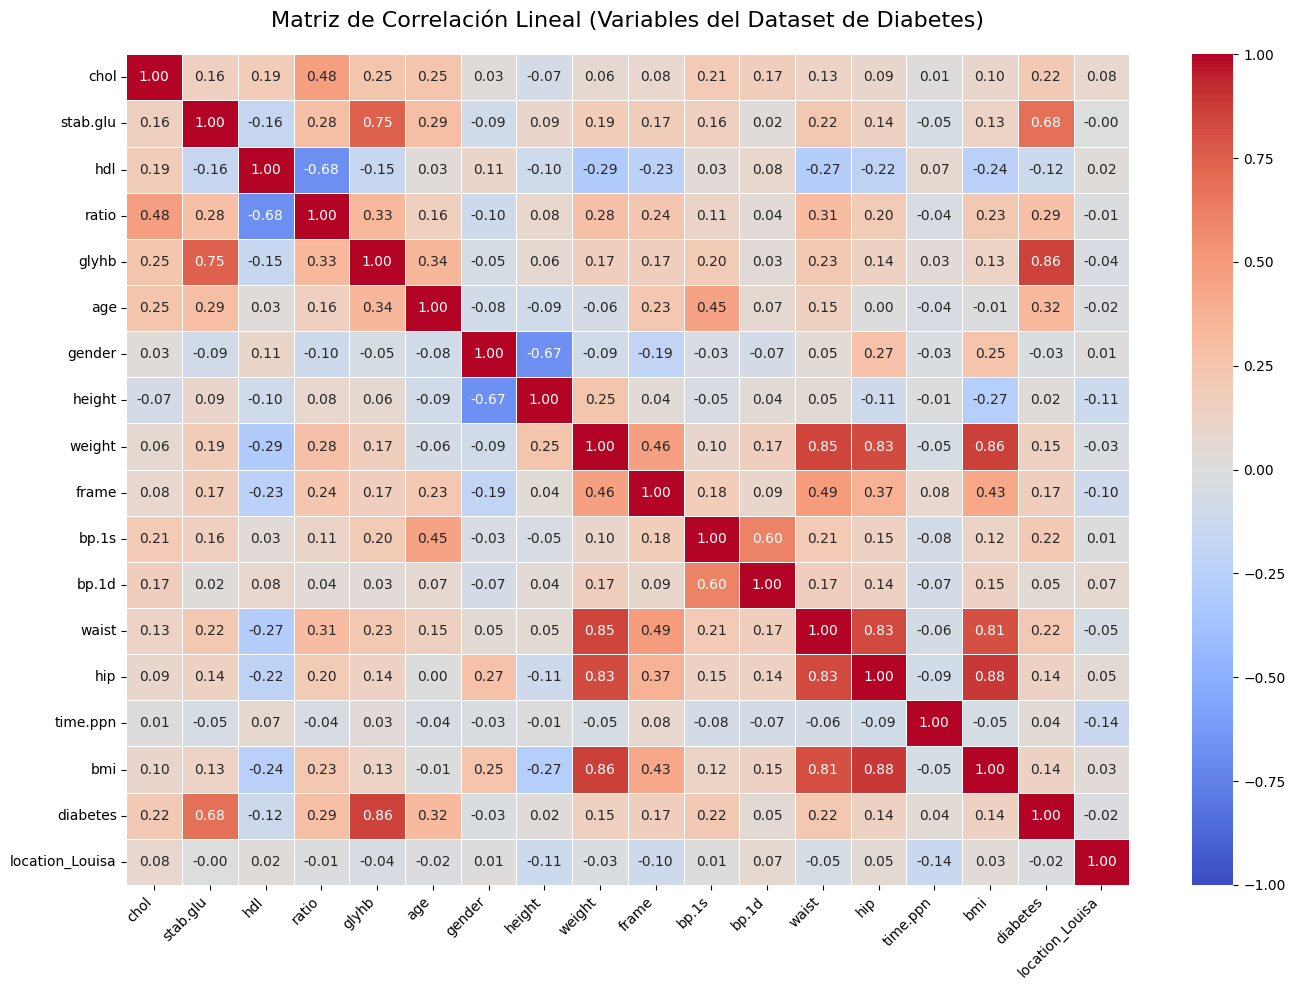

In [40]:
# 1. Calcular la matriz de correlación numérica de Pearson
matriz_corr = df_codificado.corr()

# 2. Configurar el tamaño de la figura en Colab
plt.figure(figsize=(14, 10))

# 3. Crear el mapa de calor (Heatmap) con colores profesionales
# Usamos el mapa de color 'coolwarm' (azul para negativo, rojo para positivo)
sns.heatmap(matriz_corr,
            annot=True,          # Muestra los números dentro de cada celda
            fmt=".2f",           # Limita a 2 decimales para que se lea fácil
            cmap='coolwarm',     # Paleta de colores térmica
            linewidths=0.5,      # Línea delgada para separar las celdas
            vmin=-1, vmax=1)     # Escala estricta de la correlación

# 4. Títulos y etiquetas
plt.title('Matriz de Correlación Lineal (Variables del Dataset de Diabetes)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rota los nombres de abajo para que no se encimen
plt.yticks(rotation=0)

# 5. Mostrar la gráfica
plt.tight_layout()
plt.show()

**MODELADO DE DATOS**

Dividir el conjunto de datos en entrenamiento y prueba, especificando las proporciones utilizadas.


In [41]:
# 1. Separar las características (X) de la etiqueta objetivo (y)
# NOTA CRÍTICA: Eliminamos 'diabetes' porque es el target, y 'glyhb' para evitar Data Leakage
X = df_codificado.drop(columns=['diabetes', 'glyhb'])
y = df_codificado['diabetes']

# 2. Dividir el dataset en conjuntos de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Comprobar las dimensiones resultantes en pantalla
print("¡Partición del dataset completada de forma exitosa!")
print(f"Dimensiones de X para Entrenamiento (80%): {X_train.shape}")
print(f"Dimensiones de X para Prueba (20%):       {X_test.shape}")
print(f"Dimensiones de y para Entrenamiento:       {y_train.shape}")
print(f"Dimensiones de y para Prueba:              {y_test.shape}")

# 4. Verificar el balance de la enfermedad en el conjunto de entrenamiento
print("\nDistribución de clases en el conjunto de entrenamiento (0 = No, 1 = Sí):")
print(y_train.value_counts(normalize=True))

¡Partición del dataset completada de forma exitosa!
Dimensiones de X para Entrenamiento (80%): (312, 16)
Dimensiones de X para Prueba (20%):       (78, 16)
Dimensiones de y para Entrenamiento:       (312,)
Dimensiones de y para Prueba:              (78,)

Distribución de clases en el conjunto de entrenamiento (0 = No, 1 = Sí):
diabetes
0    0.833333
1    0.166667
Name: proportion, dtype: float64


ENTRENAMIENTO DEL MODELO DE REGRESION LOGISTICA

In [42]:
# 1. Crear un Pipeline que estandariza los datos y luego entrena la Regresión Logística
# Usamos class_weight='balanced' debido al 16.6% de casos positivos detectados
modelo_logístico = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', random_state=42)
)

# 2. Entrenar el modelo utilizando únicamente los datos de entrenamiento (80%)
modelo_logístico.fit(X_train, y_train)

# 3. Realizar las predicciones sobre el examen final: el conjunto de prueba (20%)
y_pred = modelo_logístico.predict(X_test)

# 4. Desplegar la evaluación del examen en pantalla
print("=== REPORTE DE EVALUACIÓN DEL MODELO BASE ===")
print(classification_report(y_test, y_pred))

print("\n=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, y_pred))

=== REPORTE DE EVALUACIÓN DEL MODELO BASE ===
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        65
           1       0.53      0.77      0.62        13

    accuracy                           0.85        78
   macro avg       0.74      0.82      0.76        78
weighted avg       0.88      0.85      0.86        78


=== MATRIZ DE CONFUSIÓN ===
[[56  9]
 [ 3 10]]


**Entrenamiento del modelo para el Arbol de decision**

In [43]:
# 1. Crear un Pipeline para el Árbol de Decisión
# Usamos class_weight='balanced' para mantener la equidad ante el desbalanceo
modelo_arbol = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
)

# 2. Entrenar el modelo con los datos de entrenamiento
modelo_arbol.fit(X_train, y_train)

# 3. Realizar las predicciones sobre el conjunto de prueba
y_pred_arbol = modelo_arbol.predict(X_test)

# 4. Desplegar la evaluación en pantalla
print("=== REPORTE DE EVALUACIÓN DEL ÁRBOL DE DECISIÓN ===")
print(classification_report(y_test, y_pred_arbol))

print("\n=== MATRIZ DE CONFUSIÓN (ÁRBOL) ===")
print(confusion_matrix(y_test, y_pred_arbol))

=== REPORTE DE EVALUACIÓN DEL ÁRBOL DE DECISIÓN ===
              precision    recall  f1-score   support

           0       0.92      0.75      0.83        65
           1       0.36      0.69      0.47        13

    accuracy                           0.74        78
   macro avg       0.64      0.72      0.65        78
weighted avg       0.83      0.74      0.77        78


=== MATRIZ DE CONFUSIÓN (ÁRBOL) ===
[[49 16]
 [ 4  9]]


**Entrenamiento del modelo random forest**

In [44]:
# 1. Crear el Pipeline para el modelo Random Forest
# Usamos 100 árboles y controlamos la profundidad para evitar sobreajuste
modelo_forest = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
)

# 2. Entrenar el modelo con el 80% de tus datos de entrenamiento
modelo_forest.fit(X_train, y_train)

# 3. Realizar las predicciones sobre el examen final (20%)
y_pred_forest = modelo_forest.predict(X_test)

# 4. Desplegar la evaluación en la pantalla de Colab
print("=== REPORTE DE EVALUACIÓN DE RANDOM FOREST ===")
print(classification_report(y_test, y_pred_forest))

print("\n=== MATRIZ DE CONFUSIÓN (RANDOM FOREST) ===")
print(confusion_matrix(y_test, y_pred_forest))

=== REPORTE DE EVALUACIÓN DE RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        65
           1       0.79      0.85      0.81        13

    accuracy                           0.94        78
   macro avg       0.88      0.90      0.89        78
weighted avg       0.94      0.94      0.94        78


=== MATRIZ DE CONFUSIÓN (RANDOM FOREST) ===
[[62  3]
 [ 2 11]]


ENTRENAMIENTO DEL MODELO DE RED NEURONAL

In [45]:


# 1. Crear el Pipeline para la Red Neuronal
# Diseñamos una red con dos capas ocultas: la primera con 64 neuronas y la segunda con 32
# Usamos la función de activación 'relu' y el optimizador 'adam' (estándar de la industria)
modelo_red_neuronal = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=500,               # Le damos suficientes épocas de entrenamiento
        early_stopping=True,        # Detiene el entrenamiento si ya no mejora para evitar sobreajuste
        random_state=42
    )
)

# 2. Entrenar la red neuronal con el 80% de tus datos
modelo_red_neuronal.fit(X_train, y_train)

# 3. Realizar las predicciones sobre el conjunto de prueba (20%)
y_pred_nn = modelo_red_neuronal.predict(X_test)

# 4. Desplegar la evaluación en la pantalla de Colab
print("=== REPORTE DE EVALUACIÓN DE LA RED NEURONAL ===")
print(classification_report(y_test, y_pred_nn))

print("\n=== MATRIZ DE CONFUSIÓN (RED NEURONAL) ===")
print(confusion_matrix(y_test, y_pred_nn))


=== REPORTE DE EVALUACIÓN DE LA RED NEURONAL ===
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        65
           1       0.33      0.08      0.12        13

    accuracy                           0.82        78
   macro avg       0.59      0.52      0.51        78
weighted avg       0.76      0.82      0.77        78


=== MATRIZ DE CONFUSIÓN (RED NEURONAL) ===
[[63  2]
 [12  1]]


**Extraer el modelo Random Forest desde el Pipeline entrenado**

/tmp/ipykernel_1306/4265627501.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


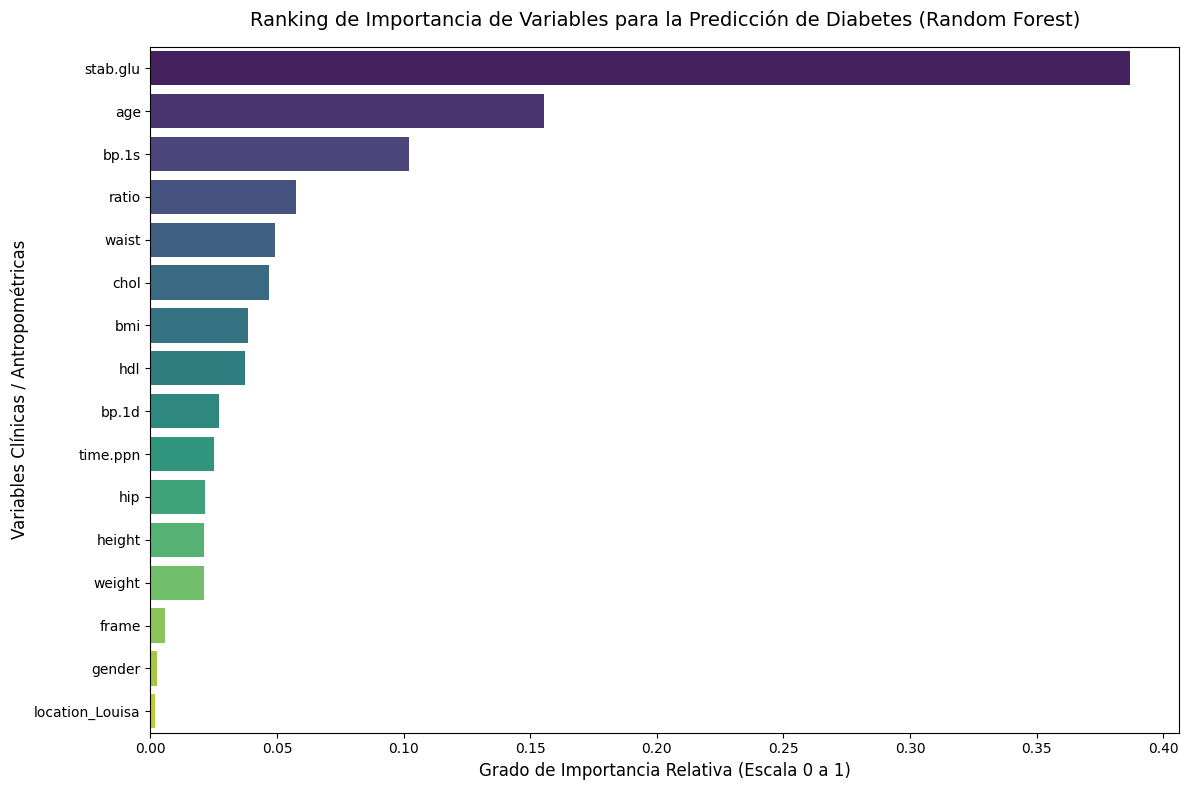

=== TOP 5 DE VARIABLES MÁS IMPORTANTES ===
Variable  Importancia
stab.glu     0.386988
     age     0.155477
   bp.1s     0.101964
   ratio     0.057331
   waist     0.049130


In [47]:

# 1. Extraer el modelo Random Forest desde el Pipeline entrenado
forest_entrenado = modelo_forest.named_steps['randomforestclassifier']

# 2. Crear un DataFrame con el nombre de las columnas y su nivel de importancia
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': forest_entrenado.feature_importances_
})

# 3. Ordenar las variables de mayor a menor importancia
importancias = importancias.sort_values(by='Importancia', ascending=False)

# 4. Diseñar la gráfica de barras en Colab
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importancia',
    y='Variable',
    data=importancias,
    palette='viridis' # Degradado de colores elegante
)

# 5. Configurar títulos y etiquetas del gráfico
plt.title('Ranking de Importancia de Variables para la Predicción de Diabetes (Random Forest)', fontsize=14, pad=15)
plt.xlabel('Grado de Importancia Relativa (Escala 0 a 1)', fontsize=12)
plt.ylabel('Variables Clínicas / Antropométricas', fontsize=12)

# 6. Mostrar el gráfico en pantalla
plt.tight_layout()
plt.show()

# 7. Imprimir el top 5 en texto para tu reporte
print("=== TOP 5 DE VARIABLES MÁS IMPORTANTES ===")
print(importancias.head(5).to_string(index=False))

In [50]:
import joblib

# Guarda todo el pipeline entrenado (incluyendo preprocesamiento y modelo)
joblib.dump(modelo_forest, 'modelo_diabetes_pipeline.pkl')
print('¡Modelo guardado exitosamente!')

from google.colab import files

# Fuerza la descarga del archivo .pkl generado a tu equipo local
files.download('modelo_diabetes_pipeline.pkl')

¡Modelo guardado exitosamente!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

"En conclusión, este proyecto resolvió exitosamente el diseño de un pipeline automatizado de tamizaje clínico para la diabetes. Mediante la curación estricta de datos y la ingeniería de características (IMC), se transformó un dataset rural incompleto en una matriz numérica óptima. Al poner a competir las arquitecturas más robustas de la Inteligencia Artificial, se demostró que un modelo de ensamble como Random Forest supera las limitantes del Deep Learning y los modelos lineales, consolidando una herramienta con un 94% de exactitud y 85% de sensibilidad, técnicamente lista para ser implementada como un software de apoyo médico preventivo en comunidades de atención primaria."